In [53]:
import commNumWL
import importlib
importlib.reload(commNumWL)
from commNumWL import Modem, Mesure, Source, Canal
import matplotlib.pyplot as plt
import numpy as np
import scipy

# Emetteur 16QAM #

Le bloc supplémentaire (en émission et réception) pour une modulation sur fréquence porteur par rapport aux modulations en bande de base est le bloc de **translation de fréquence**.<br>
Son rôle est de translater le spectre du signal émis dans la bande de fréquences désirée.

Pour une moduation PAM ou ASK, les symboles de modulation sont des symboles **réels**.<br>
Pour une modulation PSK ou QAM, les symboles de modulation sont des symboles **complexes**

### Signal 16QAM ###

16QAM : 1 symbole transporte 4 bits<br>
Nombre de symboles voulus : 50<br>

Puisque chaque symbole transporte 4 bits, le nombre total de bits ($ N_{bits} $) requis pour générer 50 symboles est donné par :<br>
$N_{bits} = Nombres \ de  \ symboles \times \ bits \ par \ symboles$<br>
$N_{bits} = 50 \times 4 $<br>
$N_{bits} = 200 $<br>


In [54]:
#Génération d'une séquence binaire pseudo aléatoire sur 20 bits
Bits = Source.random(200)

In [55]:
#Création d'un objet nommé modem16QAM par instantiation de la classe Modem
modem16QAM = Modem('QAM', 16, Bits)

#Visualisation d'attributs de l'objet modemPAM4 (créés dans le constructeur)
print(f"La valeur des symboles numériques est:\n{modem16QAM.symbs_num}\n")

#Application d'un maping sur la séquence binaire grâce à une methode
Symbs_16QAM = modem16QAM.mapping(np.sqrt(2))
print(f"La valeur des symboles de modulation est:\n {Symbs_16QAM}")

La valeur des symboles numériques est:
[[1 0 0 0]
 [1 1 0 1]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 1 1]
 [0 1 1 0]
 [1 1 1 0]
 [0 1 0 0]
 [1 1 0 0]
 [1 0 0 1]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [1 1 1 1]
 [1 0 0 1]
 [0 1 0 1]
 [1 0 1 1]
 [1 0 0 1]
 [0 1 1 0]
 [1 0 1 0]
 [0 0 1 1]
 [1 1 0 1]
 [0 1 1 0]
 [0 0 1 0]
 [1 1 1 0]
 [1 0 0 1]
 [1 0 1 1]
 [0 0 0 1]
 [1 0 0 0]
 [0 0 1 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 1 1]
 [0 0 1 1]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 1]
 [0 0 1 1]
 [0 0 1 1]
 [1 1 0 0]
 [1 0 1 0]
 [1 0 0 0]
 [0 1 1 0]
 [1 1 1 0]
 [0 0 1 1]
 [0 0 1 1]
 [1 1 1 0]
 [0 0 0 1]
 [0 1 0 1]
 [0 0 1 1]]

La valeur des symboles de modulation est:
 [ 3.+3.j  1.-1.j -3.-3.j -1.+3.j -1.-1.j -1.-3.j  1.+3.j -1.+3.j  1.-3.j
  3.+1.j -1.+3.j -1.+3.j -1.+3.j  1.+1.j  3.+1.j -1.+1.j  3.-1.j  3.+1.j
 -1.-3.j  3.-3.j -3.+1.j  1.-1.j -1.-3.j -3.+3.j  1.+3.j  3.+1.j  3.-1.j
 -3.-1.j  3.+3.j -3.+1.j -1.-3.j -1.-1.j  3.-1.j -3.+1.j  3.+3.j -3.-1.j
 -3.+1.j -3.+1.j -3.+1.j  1.-3.j  3.-3.j  3.+3.j -1.-3.j  1.+3.j -3.+1.j
 

### Affichage des bits et des symboles modulés ###

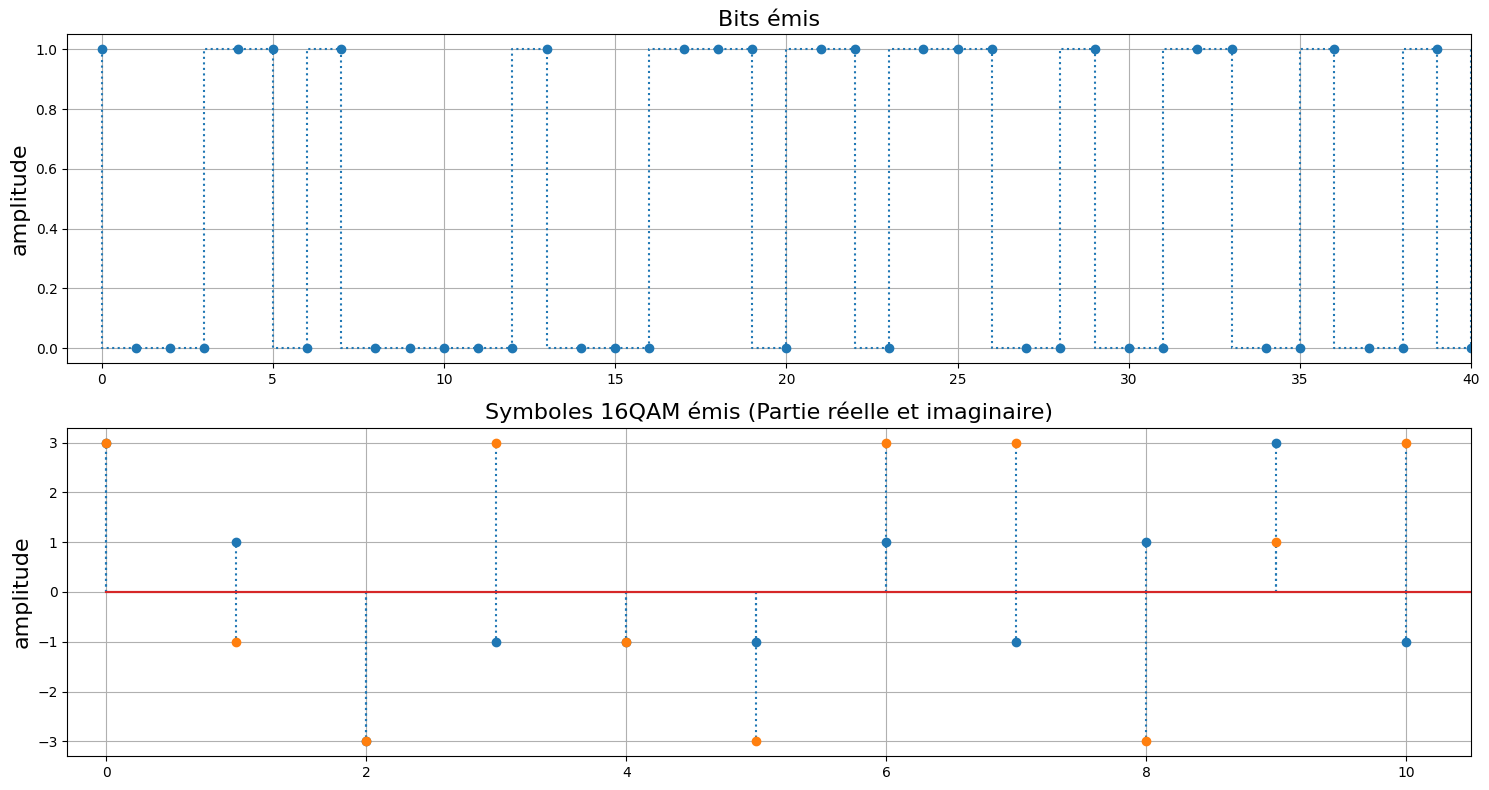

In [56]:
#Vecteur d'échantillons
t1 = np.arange(0, len(Bits))
t2 = np.arange(0, len(Symbs_16QAM))

#Affichage des symboles de modulés puis du signal 16QAM après filtre de mis en forme
fig, ax = plt.subplots(2, 1, figsize = (15,8))

ax[0].step(t1 , Bits, ':o')
ax[0].set_title('Bits émis', fontsize = 16)
ax[0].set_ylabel('amplitude', fontsize = 16)
ax[0].set_xlim(-1, 40)
ax[0].grid()

ax[1].stem(t2, np.real(Symbs_16QAM), ':o')
ax[1].stem(t2, np.imag(Symbs_16QAM), ':o')
ax[1].set_xlim(-0.3, 10.5)
ax[1].grid()
ax[1].set_title('Symboles 16QAM émis (Partie réelle et imaginaire)', fontsize = 16)
ax[1].set_ylabel('amplitude', fontsize = 16)

plt.tight_layout()

### Diagramme de constellation 16QAM ###

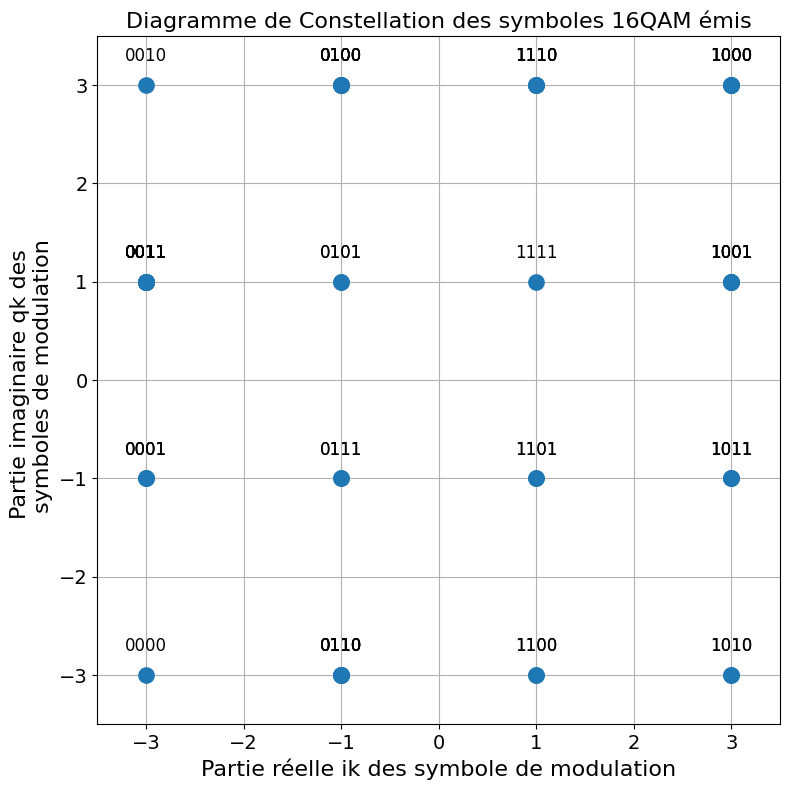

In [57]:
Mesure.constellation(Symbs_16QAM, modem16QAM.symbs_num, width=8, title='Diagramme de Constellation des symboles 16QAM émis')

**Données:**
- $ R = 50 $
- $ \frac{1}{T_S} = 50 $
- $ T_S = \frac{1}{50} $
- $ T_S = 0.02 $

**Pour 16QAM:**
- 4 bits par symbole
- $ T_b = \frac{T_S}{4} $
- $ T_b = 0.005 $
- $ D = \frac{1}{T_b} $
- $ D = 200 $

**Echantillonage:**
- $ f_e = 10^3 $
- $ f_e = R \times \text{upsampling} $
- $ \text{upsampling} = \frac{f_e}{R} $
- $ \text{upsampling} = \frac{10^3}{50} $
- $ \text{upsampling} = 200 $

**Fréquence porteuse:**
- $ f_p = 500 $


In [58]:
#Paramètres de la modulation
R = 50
fe = 10e3
te = 1/fe
fp = 500
upsampling = int(fe/R)

### Filtre de mise en forme rectangulaire ###

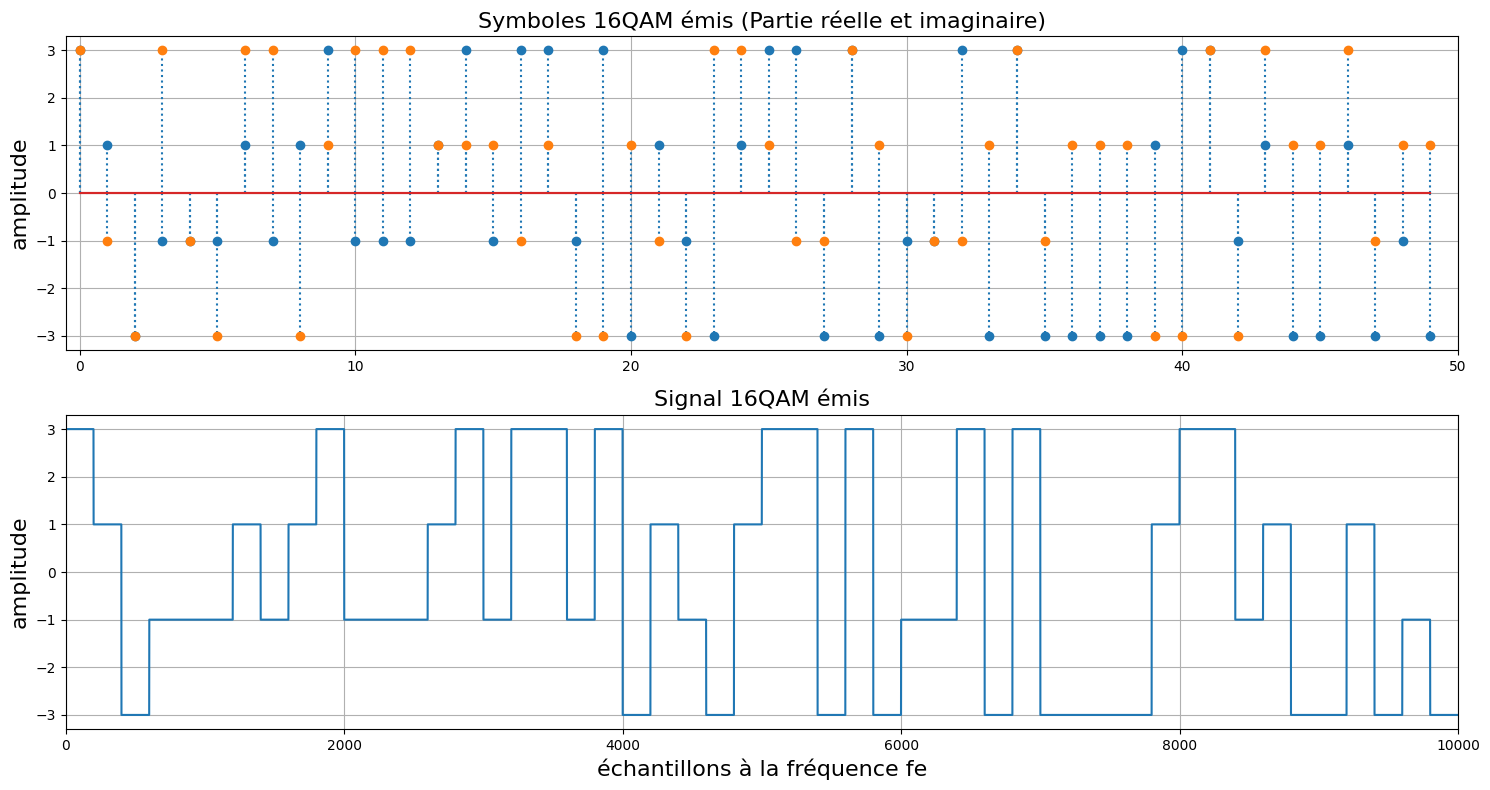

In [59]:
#Filtre de mise en forme
Signal_16QAM = modem16QAM.filtre_MF(Symbs_16QAM, upsampling)

ech = np.arange(0, len(Signal_16QAM))

fig, ax = plt.subplots(2, 1, figsize = (15,8))

ax[0].stem(t2, np.real(Symbs_16QAM), ':o')
ax[0].stem(t2, np.imag(Symbs_16QAM), ':o')
ax[0].set_xlim(-0.5, 50)
ax[0].grid()
ax[0].set_title('Symboles 16QAM émis (Partie réelle et imaginaire)', fontsize = 16)
ax[0].set_ylabel('amplitude', fontsize = 16)

ax[1].plot(ech, np.real(Signal_16QAM))
ax[1].set_xlim(0, 10000)
ax[1].set_title('Signal 16QAM émis', fontsize = 16)
ax[1].set_xlabel('échantillons à la fréquence fe', fontsize = 16)
ax[1].set_ylabel('amplitude', fontsize = 16)
ax[1].grid()

plt.tight_layout()

### Upconversion et affichage du signal 16QAM ###

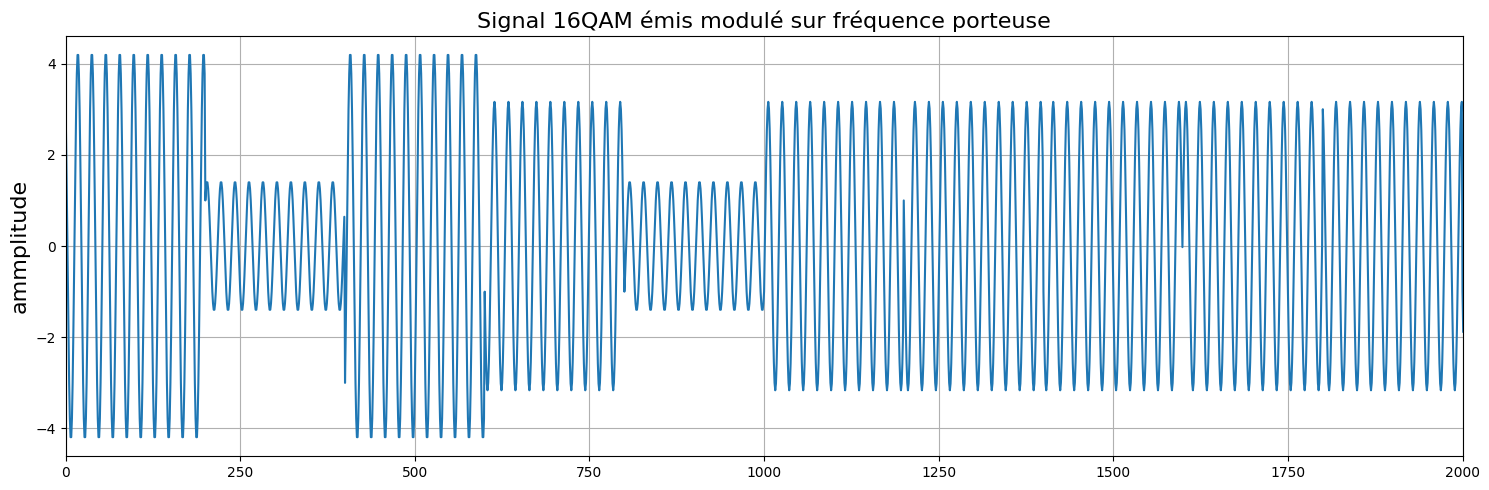

In [60]:
#Enveloppe complexe modulée sur fréquence porteuse
Signal_16QAM_translate = modem16QAM.upconv(Signal_16QAM, fp, te)

ech = np.arange(0, len(Signal_16QAM_translate))

#Affichage du graphique
fig, ax = plt.subplots(figsize = (15, 5))

ax.plot(ech, Signal_16QAM_translate)
ax.set_xlim(0, 2000)
ax.set_title('Signal 16QAM émis modulé sur fréquence porteuse', fontsize = 16)
ax.set_ylabel('ammplitude', fontsize = 16)
ax.grid()

plt.tight_layout()

### Canal AWGN ###

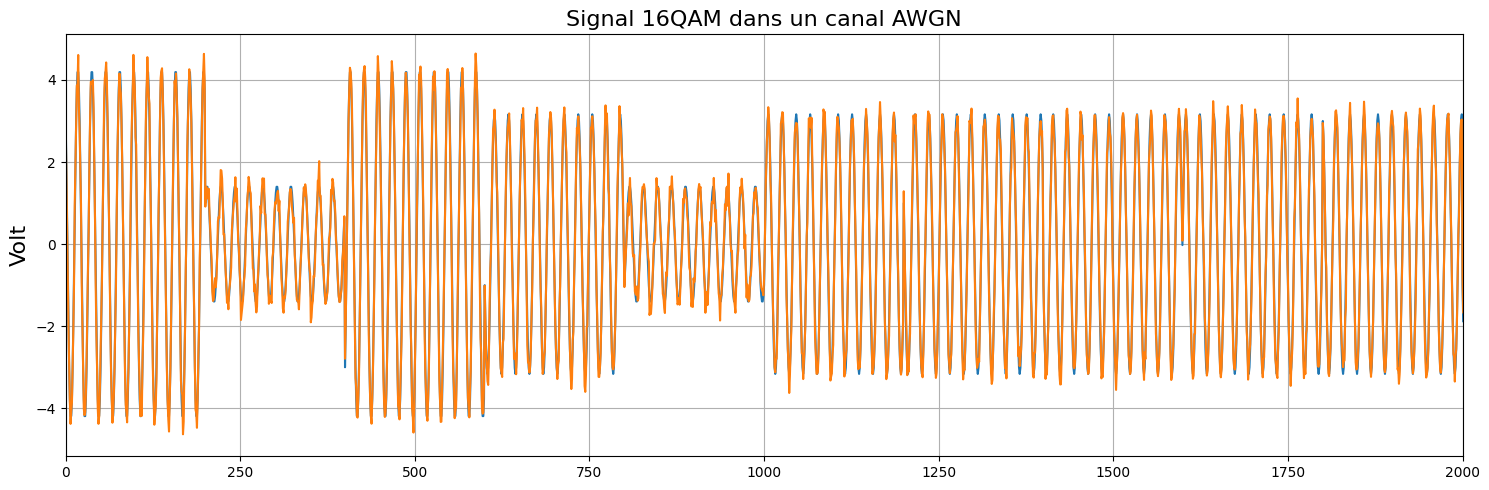

In [61]:
#Ajout d'un bruit blan gaussien avec une moyenne de 0 et une variance de 0.2
Signal_16QAM_bruite = Canal.awgn(Signal_16QAM_translate, 0, 0.2)

#Affichage du graphique
fig, ax = plt.subplots(figsize = (15, 5))

ech = np.arange(len(Signal_16QAM_translate))

ax.plot(ech, Signal_16QAM_translate)
ax.plot(ech, Signal_16QAM_bruite)
ax.set_xlim(0, 2000)
ax.set_ylabel('Volt', fontsize = 16)
ax.set_title('Signal 16QAM dans un canal AWGN', fontsize = 16)
ax.grid()

plt.tight_layout()

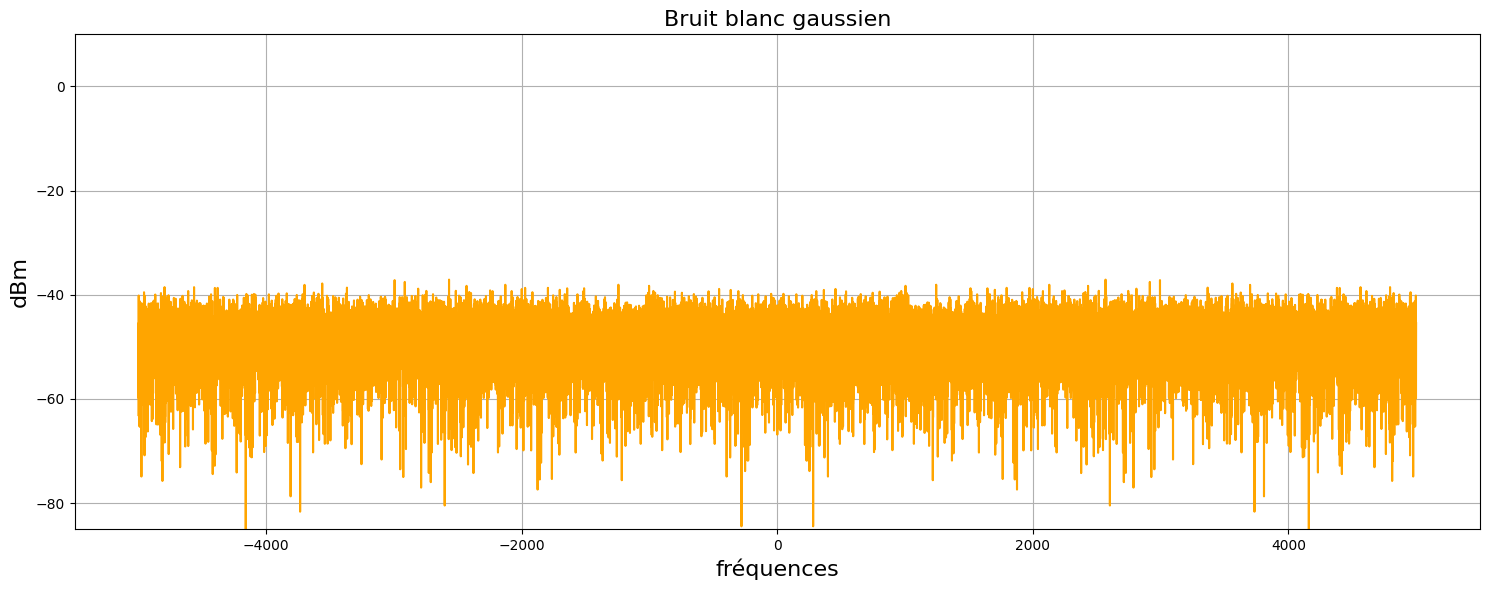

In [62]:

#Nombre d"échantillons du signal après filtre de mise en forme
num_samples = 20000
#Création du vecteur de bruit blanc gaussien
noise = np.random.normal(0, 0.2, size = num_samples)
#Addition du bruit blanc gaussien au signal

gaussien, freqG= Mesure.dsp(noise, fe, "bilateral", "dBm")

#Affichage des graphiques
fig, ax = plt.subplots(figsize = (15, 6))


#DSP du signal bruité après downconv
ax.plot(freqG, gaussien, 'orange')
# ax.set_xlim(-1500, 1500)
ax.set_ylim(-85, 10)
ax.set_xlabel('fréquences', fontsize = 16)
ax.set_ylabel('dBm', fontsize = 16)
ax.set_title('Bruit blanc gaussien', fontsize = 16)
ax.grid()

plt.tight_layout()

### Récepteur 16QAM ###

In [63]:
Signal_16QAM_down = modem16QAM.downconv(Signal_16QAM_bruite, fp, 1/10e3)

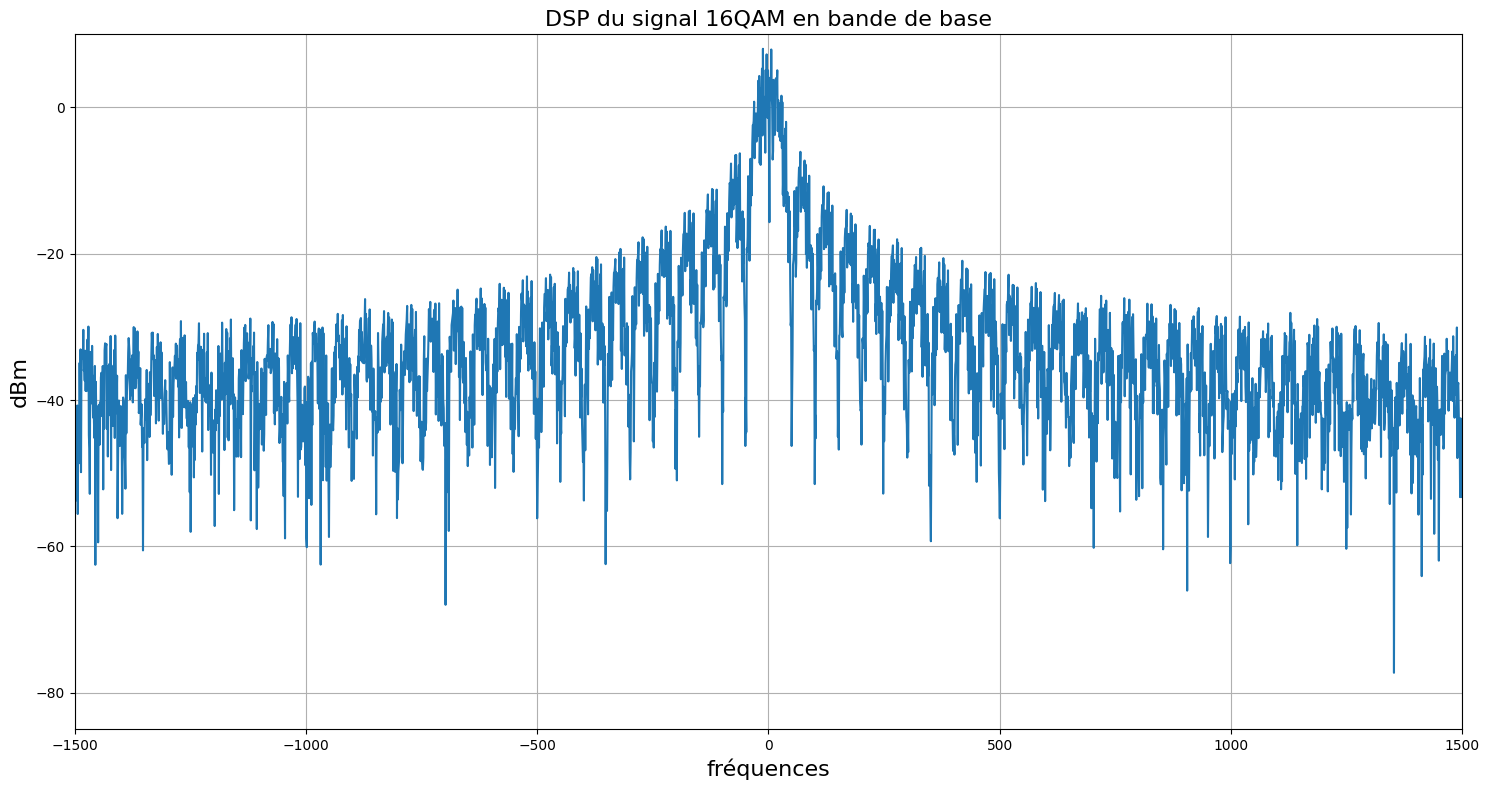

In [64]:
#Génération de la DSP des signaux grâce à une méthode de la classe Mesure
signal_16QAM_bruite_base = Canal.awgn(Signal_16QAM, 0, 0.2)
dsp_signal_16QAM_base,freq1 = Mesure.dsp(signal_16QAM_bruite_base, fe)

#Affichage des graphiques
fig, ax = plt.subplots(figsize = (15, 8))


#DSP du signal bruité après downconv
ax.plot(freq1, dsp_signal_16QAM_base)
ax.set_xlim(-1500, 1500)
ax.set_ylim(-85, 10)
ax.set_xlabel('fréquences', fontsize = 16)
ax.set_ylabel('dBm', fontsize = 16)
ax.set_title('DSP du signal 16QAM en bande de base', fontsize = 16)
ax.grid()

plt.tight_layout()

Après translation de fréquence, le spectre du signal sera centré autour de $0 \ et \ -2fp$.<br>
$fp = 500$<br>
Donc le spectre sera centré autour de $0Hz \ et \ -1000Hz$.<br>
Il faudra donc filtrer la composante spectral en $-1000Hz$.

### Affichage du signal entre avant et après translation de fréquence ###

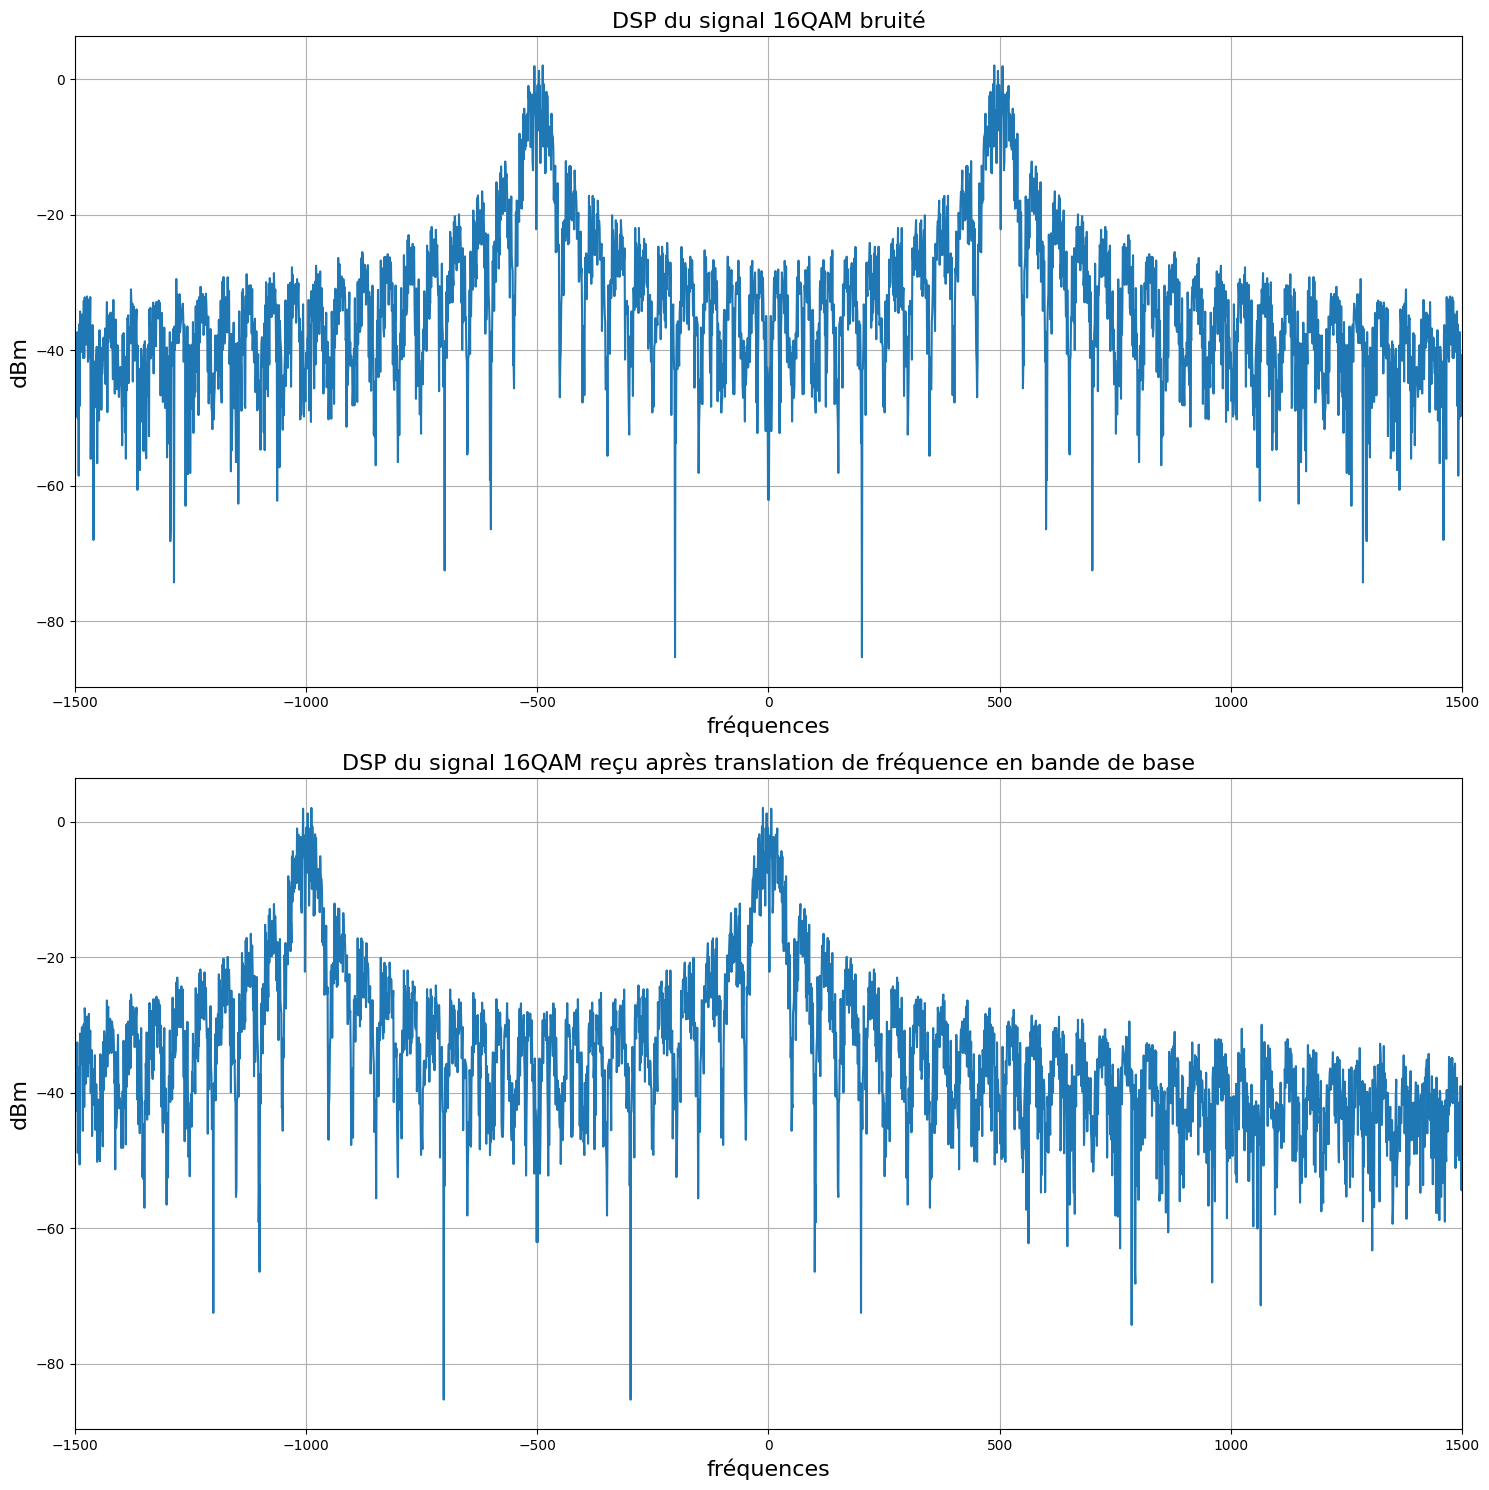

In [65]:
#Génération de la DSP des signaux grâce à une méthode de la classe Mesure
dsp_signal_16QAM_bruite,freq1 = Mesure.dsp(Signal_16QAM_bruite, fe)
dsp_signal_16QAM_down, freq2 = Mesure.dsp(Signal_16QAM_down, fe)

#Affichage des graphiques
fig, ax = plt.subplots(2, 1, figsize = (15, 15))

#DSP du signal bruité
ax[0].plot(freq1, dsp_signal_16QAM_bruite)
ax[0].set_xlim(-1500, 1500)
ax[0].set_xlabel('fréquences', fontsize = 16)
ax[0].set_ylabel('dBm', fontsize = 16)
ax[0].set_title('DSP du signal 16QAM bruité', fontsize = 16)
ax[0].grid()

#DSP du signal bruité après downconv
ax[1].plot(freq2, dsp_signal_16QAM_down)
ax[1].set_xlim(-1500, 1500)
ax[1].set_xlabel('fréquences', fontsize = 16)
ax[1].set_ylabel('dBm', fontsize = 16)
ax[1].set_title('DSP du signal 16QAM reçu après translation de fréquence en bande de base', fontsize = 16)
ax[1].grid()

plt.tight_layout()

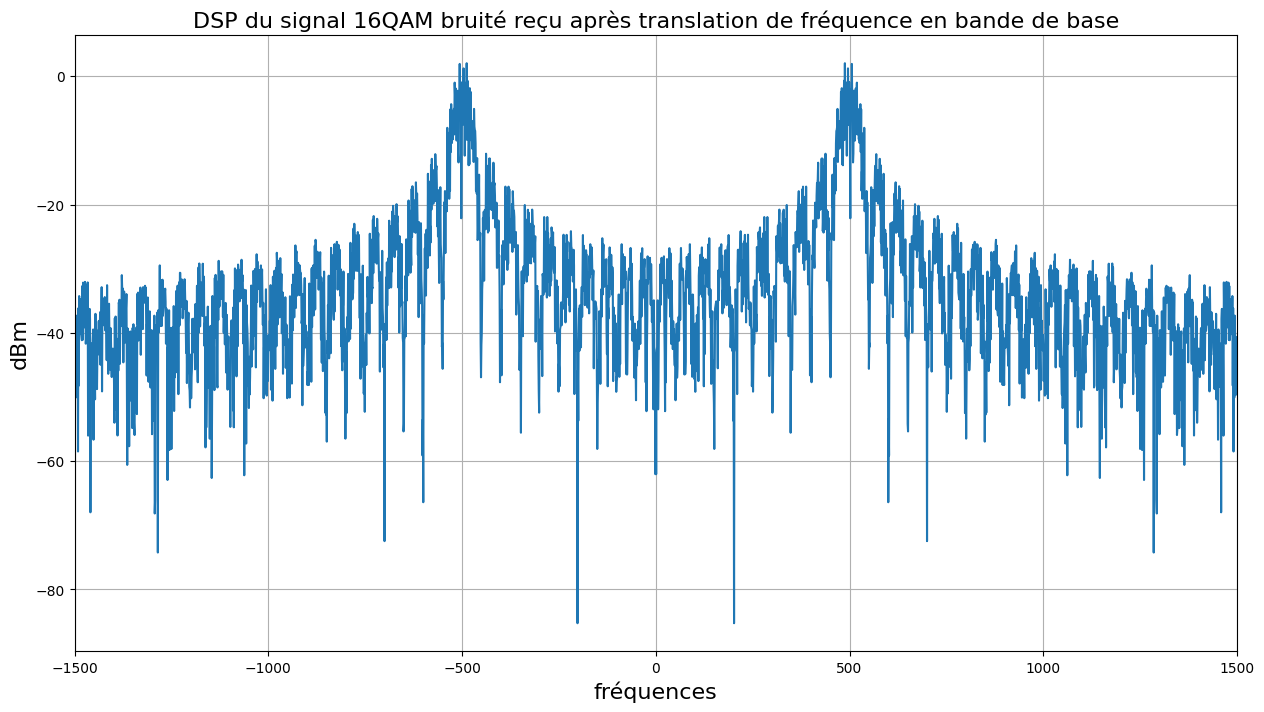

In [66]:
#Affichage des graphiques
fig, ax = plt.subplots(figsize = (15, 8))

#DSP du signal bruité après downconv
ax.plot(freq2, dsp_signal_16QAM_bruite)
ax.set_xlim(-1500, 1500)
ax.set_xlabel('fréquences', fontsize = 16)
ax.set_ylabel('dBm', fontsize = 16)
ax.set_title('DSP du signal 16QAM bruité reçu après translation de fréquence en bande de base', fontsize = 16)
ax.grid()

### Filtrage du signal 16QAM reçue ###

In [67]:
#Paramètres du filtrage
fe = 10e3
fc = 500
order = 8

#filtrage du signal down
Signal_16QAM_filtre = modem16QAM.filtre_rcv(Signal_16QAM_down, 'butter', fc, fe, order)

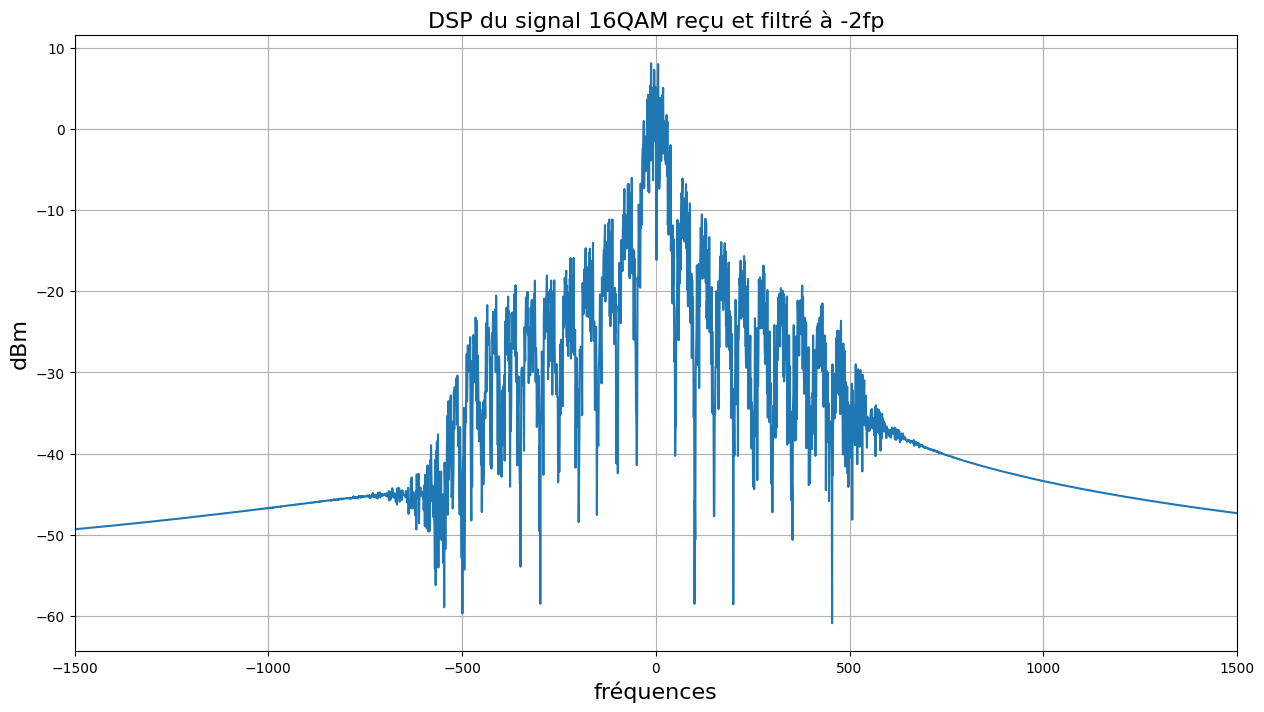

In [68]:
#Génération de la DSP des signaux grâce à une méthode de la classe Mesure
dsp_signal_16QAM_filtre, freq1 = Mesure.dsp(Signal_16QAM_filtre, fe)

#Affichage des graphiques
fig, ax = plt.subplots(figsize = (15, 8))

#DSP du signal bruité
ax.plot(freq1, dsp_signal_16QAM_filtre)
ax.set_xlim(-1500, 1500)
ax.set_xlabel('fréquences', fontsize = 16)
ax.set_ylabel('dBm', fontsize = 16)
ax.set_title('DSP du signal 16QAM reçu et filtré à -2fp', fontsize = 16)
ax.grid()

### Diagramme de constellation du signal reçu filtré ###

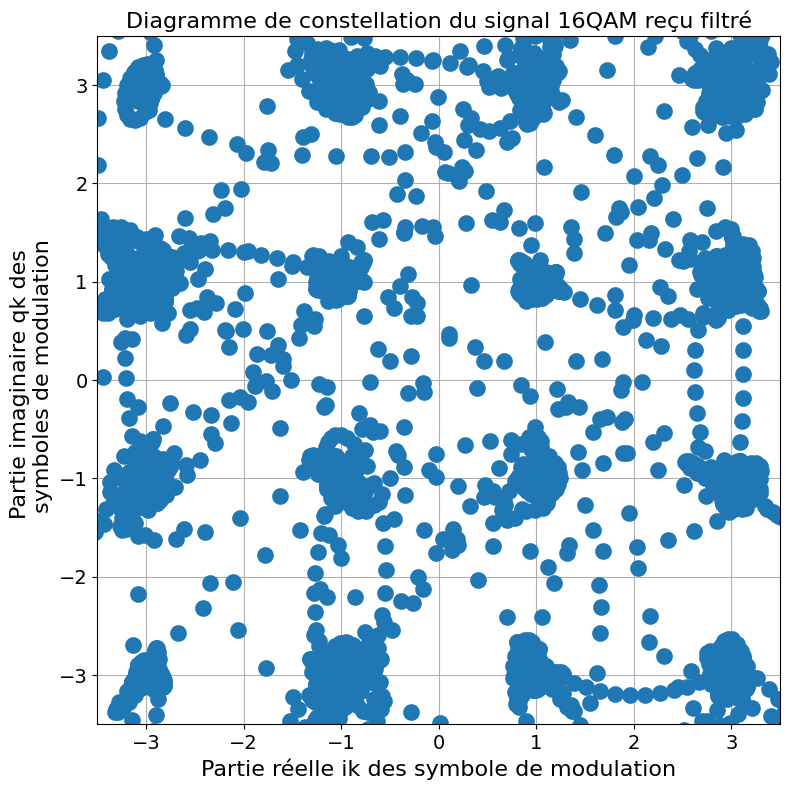

In [69]:
Mesure.constellation(Signal_16QAM_filtre, width=8, title='Diagramme de constellation du signal 16QAM reçu filtré')

### Downsampling ###

In [70]:
#Paramètre de downsampling
downsampling = upsampling
offset = int(downsampling/2)

#Downsampling du signal avec la méthode downsample de la classe modem
Symbs16QAM_rcv = modem16QAM.downsample(Signal_16QAM_filtre, downsampling, offset)

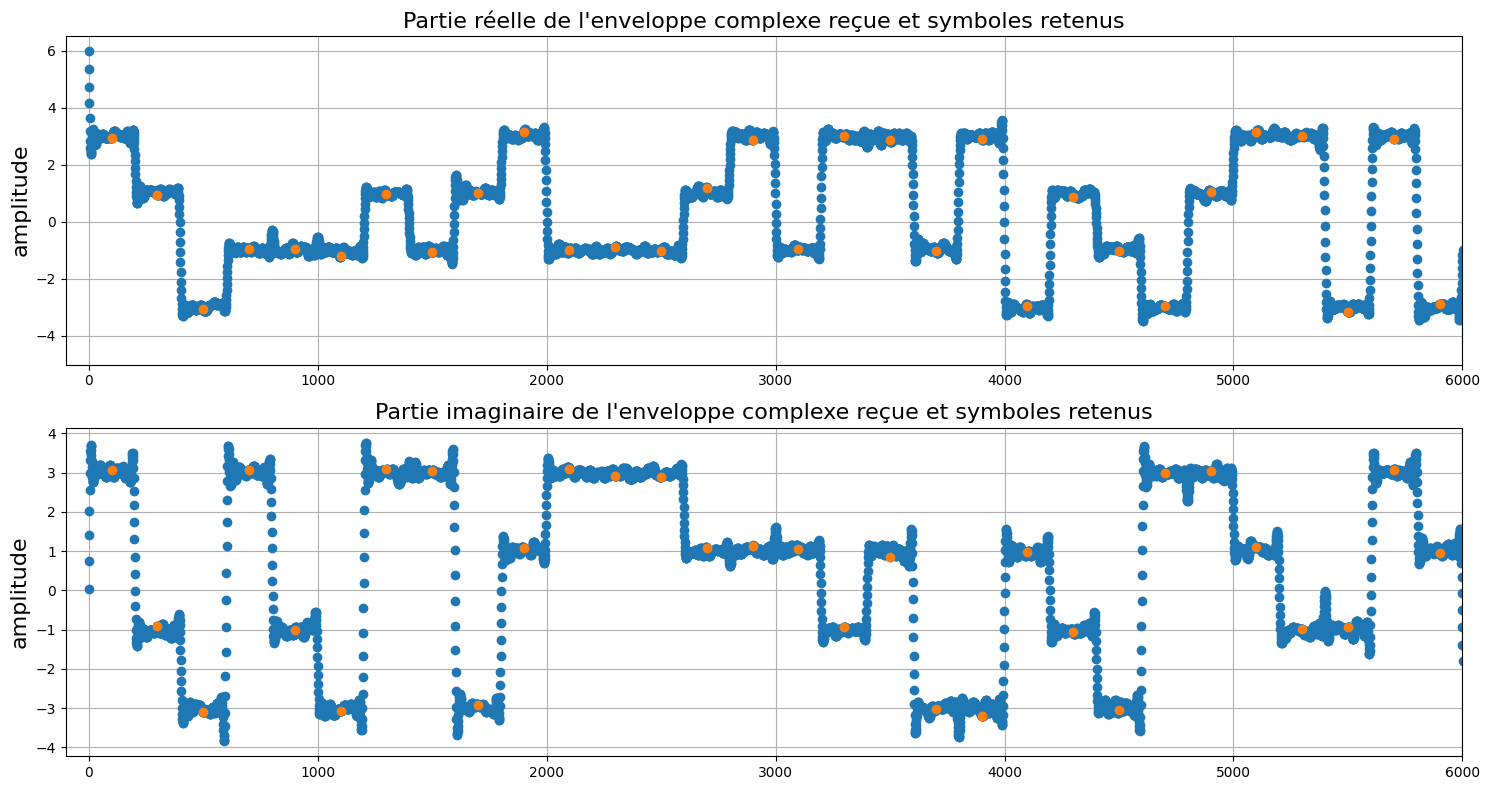

In [71]:
ech = np.arange(offset,len(Signal_16QAM_filtre), downsampling)

fig, ax =  plt.subplots(2, 1, figsize = (15,8))

ax[0].plot(np.real(Signal_16QAM_filtre), 'o')
ax[0].plot(ech, np.real(Symbs16QAM_rcv), 'o')
ax[0].set_xlim(-100,6000)
ax[0].set_ylabel('amplitude', fontsize = 16)
ax[0].set_title("Partie réelle de l'enveloppe complexe reçue et symboles retenus", fontsize = 16)
ax[0].grid()

ax[1].plot(np.imag(Signal_16QAM_filtre), 'o')
ax[1].plot(ech, np.imag(Symbs16QAM_rcv), 'o')
ax[1].set_xlim(-100,6000)
ax[1].set_ylabel('amplitude', fontsize = 16)
ax[1].set_title("Partie imaginaire de l'enveloppe complexe reçue et symboles retenus", fontsize = 16)
ax[1].grid()

plt.tight_layout()

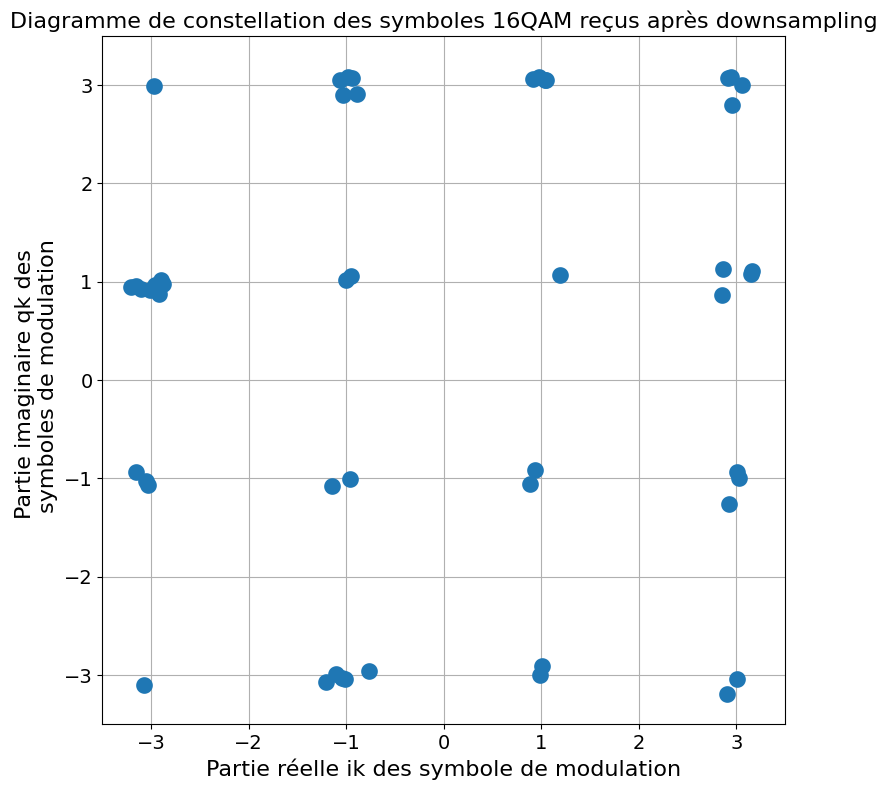

In [72]:
Mesure.constellation(Symbs16QAM_rcv, width=8, title='Diagramme de constellation des symboles 16QAM reçus après downsampling')

In [73]:
Symbs16QAM_detect = modem16QAM.detection(Symbs16QAM_rcv)
print(f'Les symboles reçus après detection sont:\n {Symbs16QAM_detect}\n')
print(f'Les symboles émis sont:\n{Symbs_16QAM}\n')


Les symboles reçus après detection sont:
 [ 3.+3.j  1.-1.j -3.-3.j -1.+3.j -1.-1.j -1.-3.j  1.+3.j -1.+3.j  1.-3.j
  3.+1.j -1.+3.j -1.+3.j -1.+3.j  1.+1.j  3.+1.j -1.+1.j  3.-1.j  3.+1.j
 -1.-3.j  3.-3.j -3.+1.j  1.-1.j -1.-3.j -3.+3.j  1.+3.j  3.+1.j  3.-1.j
 -3.-1.j  3.+3.j -3.+1.j -1.-3.j -1.-1.j  3.-1.j -3.+1.j  3.+3.j -3.-1.j
 -3.+1.j -3.+1.j -3.+1.j  1.-3.j  3.-3.j  3.+3.j -1.-3.j  1.+3.j -3.+1.j
 -3.+1.j  1.+3.j -3.-1.j -1.+1.j -3.+1.j]

Les symboles émis sont:
[ 3.+3.j  1.-1.j -3.-3.j -1.+3.j -1.-1.j -1.-3.j  1.+3.j -1.+3.j  1.-3.j
  3.+1.j -1.+3.j -1.+3.j -1.+3.j  1.+1.j  3.+1.j -1.+1.j  3.-1.j  3.+1.j
 -1.-3.j  3.-3.j -3.+1.j  1.-1.j -1.-3.j -3.+3.j  1.+3.j  3.+1.j  3.-1.j
 -3.-1.j  3.+3.j -3.+1.j -1.-3.j -1.-1.j  3.-1.j -3.+1.j  3.+3.j -3.-1.j
 -3.+1.j -3.+1.j -3.+1.j  1.-3.j  3.-3.j  3.+3.j -1.-3.j  1.+3.j -3.+1.j
 -3.+1.j  1.+3.j -3.-1.j -1.+1.j -3.+1.j]



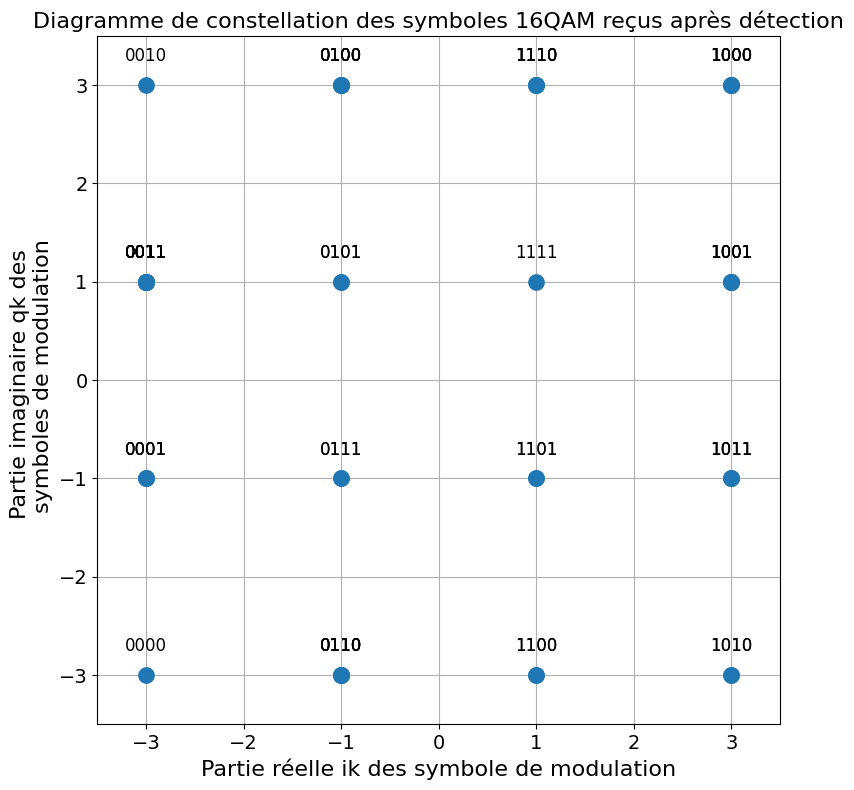

In [74]:
Mesure.constellation(Symbs16QAM_detect, modem16QAM.symbs_num, width=8, title='Diagramme de constellation des symboles 16QAM reçus après détection')

In [75]:
Bits_rcv = modem16QAM.demapping(Symbs16QAM_detect)
print(f'Les bits reçus sont:\n{Bits_rcv}\n')
print(f'Les bits envoyés sont:\n{Bits}\n')

Les bits reçus sont:
[1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0 0 1 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 1 1 0 0 1 0 1
 1 0 1 0 1 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 0 0 0
 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1
 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1
 1 1 0 0 0 0 1 0 1 0 1 0 0 1 1]

Les bits envoyés sont:
[1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0 0 1 1 0 0 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 1 1 0 0 1 0 1
 1 0 1 0 1 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 0 0 0
 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1
 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1
 1 1 0 0 0 0 1 0 1 0 1 0 0 1 1]



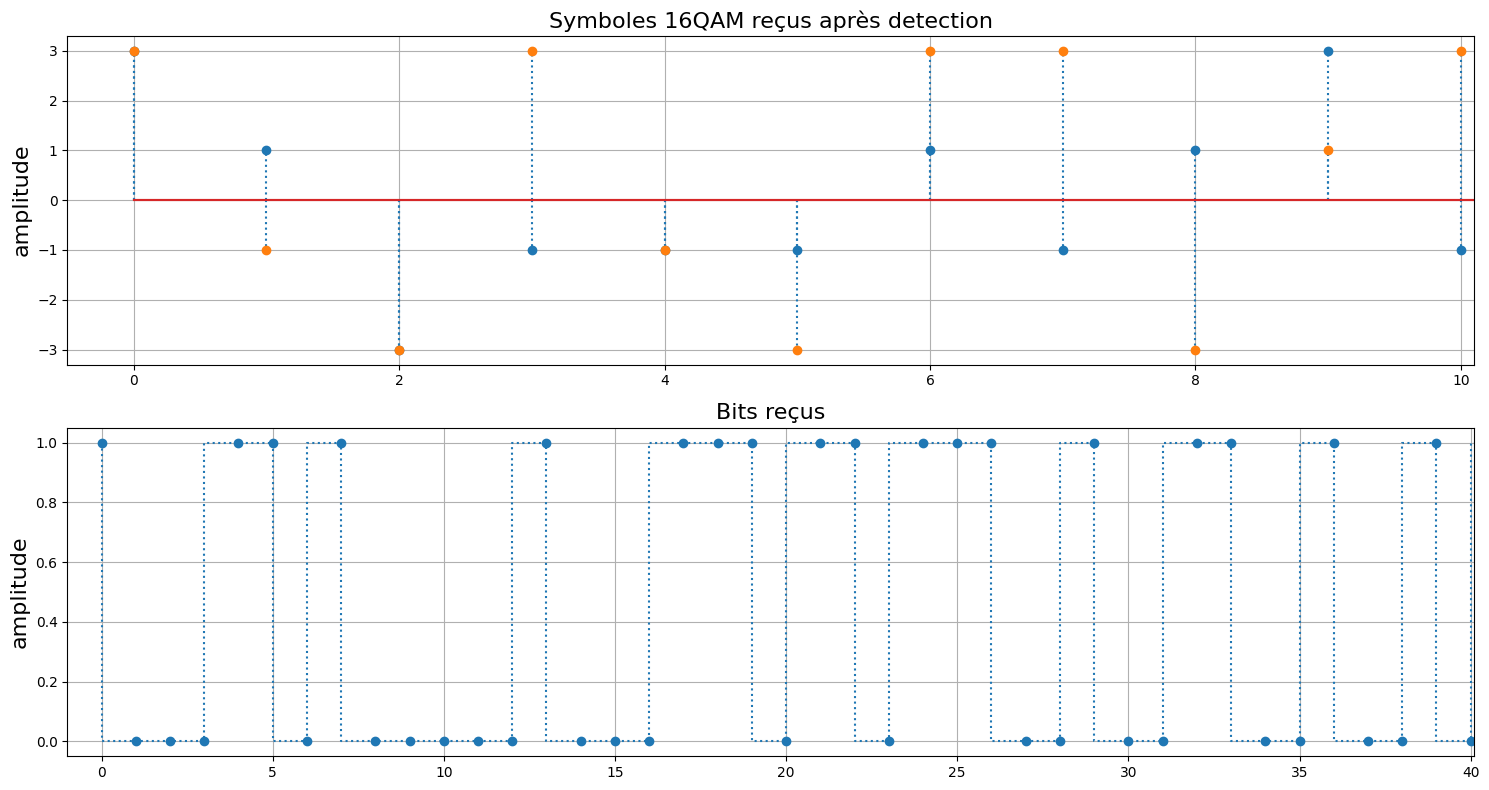

In [76]:
ech1 = np.arange(0, len(Symbs16QAM_detect))
ech2 = np.arange(0, len(Bits_rcv))

fig, ax =  plt.subplots(2, 1, figsize = (15,8))

ax[0].stem(ech1, np.real(Symbs16QAM_detect), ':o')
ax[0].stem(ech1, np.imag(Symbs16QAM_detect), ':o')
ax[0].set_xlim(-0.5,10.1)
ax[0].set_ylabel('amplitude', fontsize = 16)
ax[0].set_title('Symboles 16QAM reçus après detection', fontsize = 16)
ax[0].grid()

ax[1].step(ech2, Bits_rcv, ':o')
ax[1].set_xlim(-1, 40.1)
ax[1].set_ylabel('amplitude', fontsize = 16)
ax[1].set_title('Bits reçus', fontsize = 16)
ax[1].grid()

plt.tight_layout()

### Comparaison entre l'émission et la réception des données ###

In [77]:
taux_erreur = Mesure.comparaison(Symbs16QAM_detect, Symbs_16QAM)
print(f"Le taux d'erreur est de: {taux_erreur}%" )

Le taux d'erreur est de: 0.0%


## Envoie et réception d'un paqet ICMP avec modulation 16QAM ##

In [78]:
# ####################################################################
# ########### Caractéristiques de la transmission ####################
# ####################################################################

# #Emetteur
# umpsampling = 200

# #Upconverter
# fe = 10e3
# te = 1/fe
# fp = 500

# #Canal
# moyenne = 0
# variance = 0.2

# #downconverter
# fc = 500
# ordre = 8

# #Récepteur
# downsampling = umpsampling
# offset = int(downsampling/2)

# ####################################################################
# ############                  Emmeteur                 #############
# ####################################################################
# #Sources
# Trame_ICMP = Source.icmp('8.8.8.8', '192.168.10.4')

# #Création et initialisation des paramètres du modem (création de l'objet)
# modem16QAM = Modem('PSK', 4, Trame_ICMP)

# #Mapping
# Symbs_16QAM = modem16QAM.mapping(np.sqrt(2))

# #Filtre de mise en forme
# Signal_16QAM = modem16QAM.filtre_MF(Symbs_16QAM, umpsampling)

# ####################################################################
# ############                  Upconverter              #############
# ####################################################################
# Signal_16QAM_translate = modem16QAM.upconv(Signal_16QAM, fp, te)

# ####################################################################
# ############                 Canal AWGN               ##############
# ####################################################################
# Signal_16QAM_bruite = Canal.awgn(Signal_16QAM_translate, moyenne, variance)

# ####################################################################
# ############                 Downconverter             #############
# ####################################################################
# Signal_16QAM_down = modem16QAM.downconv(Signal_16QAM_bruite, fp, te)

# #filtrage du signal down
# Signal_16QAM_filtre = modem16QAM.filtre_rcv(Signal_16QAM_down, 'butter', fc, fe, ordre)

# ####################################################################
# ############                 Récepteur               ###############
# ####################################################################
# #Downsampling
# Symbs16QAM_rcv = modem16QAM.downsample(Signal_16QAM_filtre, downsampling, offset)

# #Détection
# Symbs16QAM_detect = modem16QAM.detection(Symbs16QAM_rcv)

# #Démapping
# Trame_ICMP_rcv = modem16QAM.demapping(Symbs16QAM_detect)

# Trame_decode = Source.decodage(Trame_ICMP_rcv)

# ####################################################################
# ############                 Affichage               ###############
# ####################################################################
# print(f'Les bits émis sont:\n{Trame_ICMP}\n')
# print (f'Les bits reçues sont:\n{Trame_ICMP_rcv}\n')
# print(f'La trame ICMP décodé est:\n')
# Trame_decode.show()

# taux_erreur = Mesure.comparaison(Trame_ICMP_rcv, Trame_ICMP)
# print(f"Le taux d'erreur est de: {taux_erreur}%" )
